In [1]:
%matplotlib widget
import threading
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import nest_asyncio
import numpy as np
from collections import deque
nest_asyncio.apply()

from phyling.ble import NanoPhyling


In [2]:
WINDOW_S = 5     # seconds of history shown
RATE     = 200   # Hz
MAX_PTS  = WINDOW_S * RATE

CHANNELS = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']

t_buf  = deque(maxlen=MAX_PTS)
bufs   = {ch: deque(maxlen=MAX_PTS) for ch in CHANNELS}

def on_data(df):
    for _, row in df.iterrows():
        t_buf.append(row['T'])
        for ch in CHANNELS:
            bufs[ch].append(row[ch])

device = NanoPhyling(
    ble_name='NanoPhyling_19',
    config={'rate': RATE, 'data': CHANNELS},
)
device.on_data(on_data)
print('Device configured.')


Device configured.


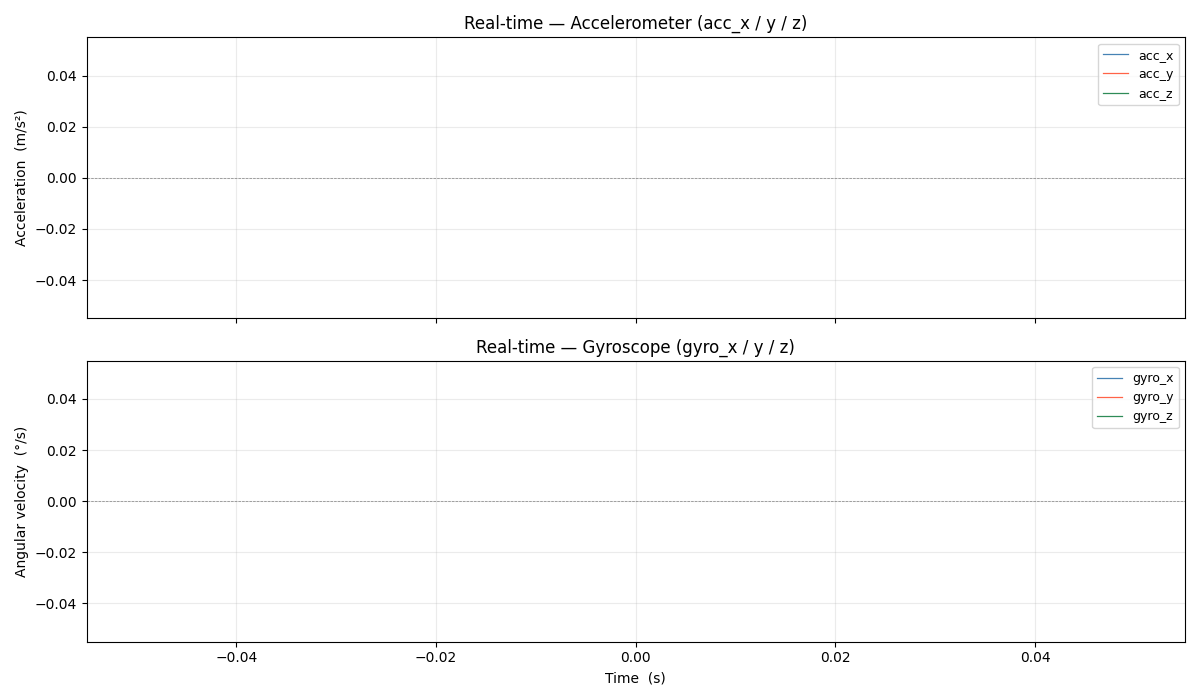

In [3]:
fig, (ax_acc, ax_gyro) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

COLORS = {'x': 'steelblue', 'y': 'tomato', 'z': 'seagreen'}

# --- Accelerometer panel ---
acc_lines = {
    ax: ax_acc.plot([], [], color=COLORS[ax], linewidth=0.9, label=f'acc_{ax}')[0]
    for ax in ('x', 'y', 'z')
}
ax_acc.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax_acc.set_ylabel('Acceleration  (m/s²)')
ax_acc.set_title('Real-time — Accelerometer (acc_x / y / z)')
ax_acc.legend(loc='upper right', fontsize=9)
ax_acc.grid(True, alpha=0.25)

# --- Gyroscope panel ---
gyro_lines = {
    ax: ax_gyro.plot([], [], color=COLORS[ax], linewidth=0.9, label=f'gyro_{ax}')[0]
    for ax in ('x', 'y', 'z')
}
ax_gyro.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax_gyro.set_ylabel('Angular velocity  (°/s)')
ax_gyro.set_xlabel('Time  (s)')
ax_gyro.set_title('Real-time — Gyroscope (gyro_x / y / z)')
ax_gyro.legend(loc='upper right', fontsize=9)
ax_gyro.grid(True, alpha=0.25)

MARGIN_ACC  = 1.0   # m/s²
MARGIN_GYRO = 50.0  # °/s

def _safe_lim(vals, margin):
    lo, hi = float(np.min(vals)), float(np.max(vals))
    span = hi - lo
    if span < margin * 2:
        mid = (lo + hi) / 2
        return mid - margin, mid + margin
    return lo - margin, hi + margin

all_lines = list(acc_lines.values()) + list(gyro_lines.values())

def update(_frame):
    if len(t_buf) < 2:
        return all_lines
    t = np.array(t_buf)

    acc_vals = np.concatenate([np.array(bufs[f'acc_{ax}']) for ax in ('x', 'y', 'z')])
    gyro_vals = np.concatenate([np.array(bufs[f'gyro_{ax}']) for ax in ('x', 'y', 'z')])

    for ax in ('x', 'y', 'z'):
        acc_lines[ax].set_data(t, np.array(bufs[f'acc_{ax}']))
        gyro_lines[ax].set_data(t, np.array(bufs[f'gyro_{ax}']))

    ax_acc.set_xlim(t[0], t[-1])
    ax_acc.set_ylim(*_safe_lim(acc_vals, MARGIN_ACC))
    ax_gyro.set_ylim(*_safe_lim(gyro_vals, MARGIN_GYRO))

    return all_lines

ani = animation.FuncAnimation(fig, update, interval=80, blit=False, cache_frame_data=False)
plt.tight_layout()
plt.show()


In [4]:
# Run in background — interrupt kernel or call device.stop() to end
t_stream = threading.Thread(target=device.run, kwargs={'duration': None}, daemon=True)
t_stream.start()
print('Streaming started.  Interrupt kernel or run device.stop() to stop.')


Scanning for BLE sensor 'NanoPhyling_19'...
Streaming started.  Interrupt kernel or run device.stop() to stop.


In [5]:
device.stop()


AttributeError: 'NanoPhyling' object has no attribute 'stop'